# Use Linear Regression To Predict Student Scores

## Objective

The objective of this report is to carry out linear regression analysis based on the available scores & other information, so as to predict below student's score based on different factors using established linear regression model:  

Gender: Male, EthnicGroup: E, ParentEduc: bachelor's degree, LunchType: standard, TestPrep: completed, ParentMaritalStatus: married, PracticeSport: sometimes, IsFirstChild: yes, NrSiblings: 3, TransportMeans: private, WklyStudyHours: 5 to 10 hours.

## Introduction

The dataset student_scores.csv records >30000 data of students' math, reading & writing score, and students related information including gender, ehnic group, parent education, lunch type, parent marital status, number of siblings, transport means, weekly study hours and etc. 

Definition of each column of student_scores.csv as below,  

- Gender : Student's gender (male/female)
- EthnicGroup : Student's ethnic (A to E)
- ParentEduc : Parent's education (from high school to master's degree)
- LunchType : Lunch type at school (standard or free/reduced)
- TestPrep : Preliminary test (completed or not)
- ParentMaritalStatus : Parent's marital status (married/single/widowed/divorced)
- PracticeSport : Frequency of student's sport practice (never/sometimes/regularly)
- IsFirstChild : If the student is the 1st child (yes/no)
- NrSiblings : Number of siblings (0 to 7)
- TransportMeans : Transport means to school (school bus/private car)
- WklyStudyHours : Weekly study hours (<5 hours; 5 to 10 hours; >10 hours)
- MathScore : Math exam score (0-100)
- ReadingScore : Reading exam score (0-100)
- WritingScore : Writing exam score (0-100)


## Read The Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
original_student_scores = pd.read_csv("student_scores.csv")
original_student_scores.head()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


## Evaluate & Clean The Data

In [3]:
cleaned_student_scores = original_student_scores.copy()
cleaned_student_scores

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,816,female,group D,high school,standard,none,single,sometimes,no,2.0,school_bus,5 - 10,59,61,65
30637,890,male,group E,high school,standard,none,single,regularly,no,1.0,private,5 - 10,58,53,51
30638,911,female,NaN,high school,free/reduced,completed,married,sometimes,no,1.0,private,5 - 10,61,70,67
30639,934,female,group D,associate's degree,standard,completed,married,regularly,no,3.0,school_bus,5 - 10,82,90,93


The original index 'Unnamed: 0' is not in sequence. In addition, the column's information will likely not have impact on the student score. Hence, will delete the column.  

In [4]:
cleaned_student_scores = cleaned_student_scores.drop('Unnamed: 0', axis=1)
cleaned_student_scores

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,female,group D,high school,standard,none,single,sometimes,no,2.0,school_bus,5 - 10,59,61,65
30637,male,group E,high school,standard,none,single,regularly,no,1.0,private,5 - 10,58,53,51
30638,female,NaN,high school,free/reduced,completed,married,sometimes,no,1.0,private,5 - 10,61,70,67
30639,female,group D,associate's degree,standard,completed,married,regularly,no,3.0,school_bus,5 - 10,82,90,93


### Tidiness Of The Data

In [5]:
cleaned_student_scores.head(10)

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75
5,female,group B,associate's degree,standard,none,married,regularly,yes,1.0,school_bus,5 - 10,73,84,79
6,female,group B,some college,standard,completed,widowed,never,no,1.0,private,5 - 10,85,93,89
7,male,group B,some college,free/reduced,none,married,sometimes,yes,1.0,private,> 10,41,43,39
8,male,group D,high school,free/reduced,completed,single,sometimes,no,3.0,private,> 10,65,64,68
9,female,group B,high school,free/reduced,none,married,regularly,yes,NaN,private,< 5,37,59,50


As seen from above, each variable as a column, each observation as a row, each cell contains a value, hence no issue.

### Cleanliness Of The Data

In [6]:
cleaned_student_scores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               30641 non-null  object 
 1   EthnicGroup          28801 non-null  object 
 2   ParentEduc           28796 non-null  object 
 3   LunchType            30641 non-null  object 
 4   TestPrep             28811 non-null  object 
 5   ParentMaritalStatus  29451 non-null  object 
 6   PracticeSport        30010 non-null  object 
 7   IsFirstChild         29737 non-null  object 
 8   NrSiblings           29069 non-null  float64
 9   TransportMeans       27507 non-null  object 
 10  WklyStudyHours       29686 non-null  object 
 11  MathScore            30641 non-null  int64  
 12  ReadingScore         30641 non-null  int64  
 13  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(3), object(10)
memory usage: 3.3+ MB


Missing value exists in: EthnicGroup, ParentEduc, TestPrep, ParentMaritalStatus, PracticeSport, IsFirstChild, NrSiblings, TransportMeans, WklyStudyHours  

Dtype change to category: Gender, EthnicGroup, ParentEduc, LunchType, TestPrep, ParentMaritalStatus, PracticeSport, IsFirstChild, TransportMeans, WklyStudyHours

In [7]:
cleaned_student_scores['Gender'] = cleaned_student_scores['Gender'].astype('category')
cleaned_student_scores['EthnicGroup'] = cleaned_student_scores['EthnicGroup'].astype('category')
cleaned_student_scores['ParentEduc'] = cleaned_student_scores['ParentEduc'].astype('category')
cleaned_student_scores['LunchType'] = cleaned_student_scores['LunchType'].astype('category')
cleaned_student_scores['TestPrep'] = cleaned_student_scores['TestPrep'].astype('category')
cleaned_student_scores['ParentMaritalStatus'] = cleaned_student_scores['ParentMaritalStatus'].astype('category')
cleaned_student_scores['PracticeSport'] = cleaned_student_scores['PracticeSport'].astype('category')
cleaned_student_scores['IsFirstChild'] = cleaned_student_scores['IsFirstChild'].astype('category')
cleaned_student_scores['TransportMeans'] = cleaned_student_scores['TransportMeans'].astype('category')
cleaned_student_scores['WklyStudyHours'] = cleaned_student_scores['WklyStudyHours'].astype('category')

In [8]:
cleaned_student_scores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Gender               30641 non-null  category
 1   EthnicGroup          28801 non-null  category
 2   ParentEduc           28796 non-null  category
 3   LunchType            30641 non-null  category
 4   TestPrep             28811 non-null  category
 5   ParentMaritalStatus  29451 non-null  category
 6   PracticeSport        30010 non-null  category
 7   IsFirstChild         29737 non-null  category
 8   NrSiblings           29069 non-null  float64 
 9   TransportMeans       27507 non-null  category
 10  WklyStudyHours       29686 non-null  category
 11  MathScore            30641 non-null  int64   
 12  ReadingScore         30641 non-null  int64   
 13  WritingScore         30641 non-null  int64   
dtypes: category(10), float64(1), int64(3)
memory usage: 1.2 MB


#### Missing Value

In [9]:
# Missing value in Ethnic Group

In [10]:
cleaned_student_scores.query('EthnicGroup.isna()')

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
32,male,NaN,some college,standard,none,married,sometimes,no,2.0,private,5 - 10,40,42,38
47,male,NaN,associate's degree,free/reduced,completed,married,regularly,no,2.0,private,< 5,76,68,68
50,female,NaN,some high school,free/reduced,completed,married,regularly,yes,NaN,private,> 10,75,86,90
88,female,NaN,some college,standard,completed,married,never,yes,0.0,school_bus,< 5,59,69,66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30499,female,NaN,associate's degree,free/reduced,completed,married,regularly,no,1.0,school_bus,5 - 10,60,78,71
30513,male,NaN,some high school,free/reduced,none,divorced,sometimes,no,2.0,NaN,5 - 10,50,48,46
30578,male,NaN,some high school,standard,none,married,sometimes,no,1.0,private,5 - 10,80,82,74
30625,female,NaN,some high school,free/reduced,completed,single,sometimes,no,3.0,private,5 - 10,47,65,68


There are ~2000 missing values in EthnicGroup. EthnicGroup is also not likely to be a critical factor for the student score.  
Hence, will keep these data.

In [11]:
# Missing value in ParentEduc

In [12]:
cleaned_student_scores.query('ParentEduc.isna()')

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
22,male,group D,NaN,standard,none,married,never,yes,5.0,NaN,5 - 10,42,53,51
24,male,group D,NaN,free/reduced,completed,married,sometimes,yes,2.0,school_bus,5 - 10,74,71,80
54,male,group D,NaN,standard,completed,married,regularly,no,1.0,private,> 10,61,60,60
70,male,group A,NaN,standard,completed,NaN,regularly,yes,NaN,NaN,5 - 10,82,79,83
98,male,group E,NaN,standard,completed,single,sometimes,yes,0.0,school_bus,5 - 10,66,63,64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30593,female,group C,NaN,standard,none,married,sometimes,no,2.0,school_bus,< 5,79,85,90
30598,male,group E,NaN,standard,completed,divorced,sometimes,no,3.0,private,5 - 10,86,83,76
30610,female,group B,NaN,standard,completed,married,regularly,no,4.0,private,5 - 10,74,84,84
30623,female,group B,NaN,standard,completed,married,regularly,no,2.0,NaN,5 - 10,75,87,87


ParentEduc is likely a critical factor that affects student score. Missing data in ParentEduc will likely affect the subsequent analysis.  
Hence, will remove these observations with missing value in ParentEduc.

In [13]:
cleaned_student_scores = cleaned_student_scores.dropna(subset=['ParentEduc'])
cleaned_student_scores['ParentEduc'].isna().sum()

np.int64(0)

In [14]:
# Missing value in TestPrep

In [15]:
cleaned_student_scores.query('TestPrep.isna()')

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
16,male,group C,high school,standard,NaN,married,sometimes,yes,0.0,school_bus,5 - 10,88,89,86
41,male,group B,some college,free/reduced,NaN,married,regularly,yes,3.0,school_bus,5 - 10,60,65,67
67,male,group C,some high school,standard,NaN,married,sometimes,yes,2.0,private,< 5,47,48,40
118,male,group D,some college,standard,NaN,married,regularly,no,3.0,school_bus,< 5,64,76,74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30471,female,NaN,some college,free/reduced,NaN,divorced,never,no,1.0,NaN,5 - 10,65,77,76
30514,male,group C,some college,free/reduced,NaN,divorced,never,no,1.0,school_bus,> 10,45,53,52
30549,male,group C,some high school,free/reduced,NaN,married,regularly,no,2.0,private,< 5,48,39,32
30577,male,group C,high school,standard,NaN,married,sometimes,no,2.0,school_bus,5 - 10,78,81,76


There are ~2000 missing values in TestPrep. TestPrep is also not likely to be a critical factor for the student score.  
Hence, will keep these data.

In [16]:
# Missing value in ParentMaritalStatus

In [17]:
cleaned_student_scores.query('ParentMaritalStatus.isna()')

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
10,male,group C,associate's degree,standard,none,NaN,sometimes,yes,1.0,private,5 - 10,58,54,52
69,male,group E,some high school,standard,none,NaN,sometimes,no,5.0,school_bus,5 - 10,28,25,21
120,female,group A,bachelor's degree,standard,none,NaN,regularly,yes,0.0,school_bus,5 - 10,52,49,52
180,female,group C,master's degree,standard,completed,NaN,regularly,yes,1.0,school_bus,< 5,69,85,87
189,female,NaN,associate's degree,standard,none,NaN,regularly,yes,2.0,school_bus,5 - 10,58,70,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30563,male,group B,some high school,free/reduced,completed,NaN,sometimes,no,4.0,private,5 - 10,64,63,60
30587,male,group E,master's degree,standard,none,NaN,regularly,no,4.0,school_bus,5 - 10,93,85,88
30604,male,group E,some high school,standard,none,NaN,sometimes,no,1.0,school_bus,5 - 10,93,77,79
30616,male,group C,high school,standard,none,NaN,never,no,3.0,private,< 5,71,68,63


ParentMaritalStatus is not likely to be a critical factor for the student score.  
Hence, will keep these data.

In [18]:
# Missing value in PracticeSport

In [19]:
cleaned_student_scores.query('PracticeSport.isna()')

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
46,male,group E,some college,standard,none,married,NaN,no,3.0,school_bus,> 10,54,55,48
183,male,group E,high school,free/reduced,none,married,NaN,no,7.0,private,> 10,56,56,52
191,male,group D,some high school,standard,completed,married,NaN,yes,NaN,school_bus,< 5,71,69,76
226,male,group D,high school,free/reduced,completed,divorced,NaN,yes,1.0,private,> 10,75,69,67
257,male,group B,some college,standard,completed,widowed,NaN,yes,1.0,school_bus,< 5,85,83,74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30241,female,group D,master's degree,standard,completed,single,NaN,no,1.0,private,< 5,93,91,99
30442,male,group B,some college,standard,completed,NaN,NaN,no,3.0,NaN,< 5,69,62,64
30446,female,group E,some college,standard,none,married,NaN,no,2.0,school_bus,> 10,77,88,81
30601,female,group C,bachelor's degree,standard,none,single,NaN,no,1.0,school_bus,> 10,59,65,65


PracticeSport is not likely to be a critical factor for the student score.  
Hence, will keep these data.

In [20]:
# Missing value in IsFirstChild

In [21]:
cleaned_student_scores.query('IsFirstChild.isna()')

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
45,male,group C,high school,standard,completed,married,sometimes,NaN,3.0,NaN,5 - 10,82,84,82
77,male,group D,high school,free/reduced,none,married,never,NaN,3.0,private,5 - 10,40,38,33
133,female,group E,some college,free/reduced,completed,single,regularly,NaN,1.0,private,< 5,41,54,54
210,female,group B,associate's degree,standard,completed,divorced,regularly,NaN,3.0,school_bus,> 10,55,67,76
217,male,group C,associate's degree,standard,none,married,regularly,NaN,1.0,private,5 - 10,47,43,43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28952,female,group C,some high school,standard,completed,married,sometimes,NaN,1.0,private,> 10,83,83,91
28963,male,group A,some college,standard,none,single,regularly,NaN,1.0,private,> 10,75,67,63
28966,male,group A,some high school,standard,none,married,regularly,NaN,0.0,private,5 - 10,63,60,58
28993,male,group C,bachelor's degree,free/reduced,none,married,sometimes,NaN,4.0,school_bus,5 - 10,65,60,62


IsFirstChild is not likely to be a critical factor for the student score.  
Hence, will keep these data.

In [22]:
# Missing value in NrSiblings

In [23]:
cleaned_student_scores.query('NrSiblings.isna()')

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
9,female,group B,high school,free/reduced,none,married,regularly,yes,NaN,private,< 5,37,59,50
34,male,group E,associate's degree,standard,completed,single,sometimes,no,NaN,school_bus,5 - 10,81,81,79
44,female,group C,high school,standard,none,married,regularly,yes,NaN,private,5 - 10,67,72,77
50,female,NaN,some high school,free/reduced,completed,married,regularly,yes,NaN,private,> 10,75,86,90
56,male,group A,some high school,free/reduced,none,married,sometimes,yes,NaN,school_bus,5 - 10,39,39,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30565,female,group A,bachelor's degree,standard,none,married,regularly,no,NaN,school_bus,< 5,71,79,78
30596,male,group C,bachelor's degree,standard,none,married,regularly,no,NaN,NaN,5 - 10,54,44,47
30602,male,group D,some college,standard,none,married,sometimes,no,NaN,private,< 5,76,74,71
30614,male,group D,bachelor's degree,standard,none,divorced,sometimes,no,NaN,school_bus,5 - 10,82,73,80


NrSiblings is not likely to be a critical factor for the student score.  
Hence, will keep these data.

In [24]:
# Missing value in TransportMeans

In [25]:
cleaned_student_scores.query('TransportMeans.isna()')

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
23,female,group C,some high school,standard,none,divorced,never,no,3.0,NaN,5 - 10,66,71,71
30,female,group B,some college,standard,none,single,sometimes,yes,5.0,NaN,5 - 10,63,65,61
40,female,group C,associate's degree,standard,none,divorced,regularly,no,1.0,NaN,5 - 10,59,74,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30560,female,group E,some college,free/reduced,completed,NaN,sometimes,no,4.0,NaN,> 10,56,72,69
30564,female,group C,associate's degree,free/reduced,none,married,regularly,no,NaN,NaN,5 - 10,58,59,63
30579,female,group D,associate's degree,standard,none,married,sometimes,no,3.0,NaN,5 - 10,95,90,98
30580,female,group B,high school,standard,none,married,regularly,no,1.0,NaN,> 10,39,45,43


TransportMeans is not likely to be a critical factor for the student score.  
Hence, will keep these data.

In [26]:
# Missing value in WklyStudyHours

In [27]:
cleaned_student_scores.query('WklyStudyHours.isna()')

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
15,female,group C,some high school,standard,none,married,sometimes,yes,0.0,private,NaN,69,75,78
33,male,group E,some college,standard,none,divorced,sometimes,yes,0.0,school_bus,NaN,97,87,82
62,male,group B,associate's degree,free/reduced,none,divorced,regularly,no,3.0,school_bus,NaN,62,58,57
74,male,group B,high school,free/reduced,none,married,sometimes,yes,0.0,private,NaN,49,45,45
114,male,group D,high school,free/reduced,none,married,sometimes,no,3.0,private,NaN,63,57,56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30508,male,group D,high school,free/reduced,completed,married,sometimes,no,1.0,school_bus,NaN,74,75,79
30520,male,group D,some high school,free/reduced,none,married,sometimes,no,1.0,school_bus,NaN,59,53,57
30541,female,group E,high school,standard,none,married,regularly,no,2.0,school_bus,NaN,87,82,83
30611,female,group D,associate's degree,free/reduced,completed,single,regularly,no,5.0,school_bus,NaN,52,66,73


WklyStudyHours is a critical factor which will affect student score. It will not be able to predict student score without information of WklyStudyHours. Hence, will delete those observations with NaN in WklyStudyHours.

#### Duplicated Value

All the variables are expected to have duplicated value. Hence, no issue. 

#### Non-standardize Value

Non-standardize value may exist in categorical variable. Hence, need to check every categorical variable.

In [28]:
cleaned_student_scores['Gender'].value_counts()

Gender
female    14513
male      14283
Name: count, dtype: int64

In [29]:
cleaned_student_scores['EthnicGroup'].value_counts()

EthnicGroup
group C    8652
group D    7056
group B    5470
group E    3814
group A    2078
Name: count, dtype: int64

In [30]:
cleaned_student_scores['ParentEduc'].value_counts()

ParentEduc
some college          6633
high school           5687
associate's degree    5550
some high school      5517
bachelor's degree     3386
master's degree       2023
Name: count, dtype: int64

"high school" & "some high school" likely refer to the same thing. Hence, should replace "some high school" with "high school".

In [31]:
cleaned_student_scores["ParentEduc"] = cleaned_student_scores["ParentEduc"].replace({"some high school":"high school"})
len(cleaned_student_scores[cleaned_student_scores["ParentEduc"] == "some high school"])

C:\Users\wcg90\AppData\Local\Temp\ipykernel_22032\4164855771.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  cleaned_student_scores["ParentEduc"] = cleaned_student_scores["ParentEduc"].replace({"some high school":"high school"})
C:\Users\wcg90\AppData\Local\Temp\ipykernel_22032\4164855771.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_student_scores["ParentEduc"] = cleaned_student_scores["ParentEduc"].replace({"some high school":"high school"})


0

In [32]:
cleaned_student_scores['LunchType'].value_counts()

LunchType
standard        18661
free/reduced    10135
Name: count, dtype: int64

In [33]:
cleaned_student_scores['TestPrep'].value_counts()

TestPrep
none         17700
completed     9374
Name: count, dtype: int64

In [34]:
cleaned_student_scores['ParentMaritalStatus'].value_counts()

ParentMaritalStatus
married     15802
single       6664
divorced     4655
widowed       559
Name: count, dtype: int64

In [35]:
cleaned_student_scores['PracticeSport'].value_counts()

PracticeSport
sometimes    14321
regularly    10151
never         3743
Name: count, dtype: int64

In [36]:
cleaned_student_scores['IsFirstChild'].value_counts()

IsFirstChild
yes    17953
no      9999
Name: count, dtype: int64

In [37]:
cleaned_student_scores['TransportMeans'].value_counts()

TransportMeans
school_bus    15190
private       10673
Name: count, dtype: int64

In [38]:
cleaned_student_scores['WklyStudyHours'].value_counts()

WklyStudyHours
5 - 10    15241
< 5        7766
> 10       4896
Name: count, dtype: int64

No other non-standardize value observed.

#### Incorrect / Invalid Value

In [39]:
cleaned_student_scores.describe()

,NrSiblings,MathScore,ReadingScore,WritingScore
count,27319.000000,28796.000000,28796.000000,28796.000000
mean,2.144405,66.552820,69.387276,68.426483
std,1.453948,15.379741,14.765339,15.452442
min,0.000000,0.000000,10.000000,4.000000
25%,1.000000,56.000000,59.000000,58.000000
50%,2.000000,67.000000,70.000000,69.000000
75%,3.000000,78.000000,80.000000,79.000000
max,7.000000,100.000000,100.000000,100.000000


No abnormal value observed.

## Explore The Data

In [40]:
sns.set_palette('pastel')

### Student Score Distribution

<Axes: ylabel='WritingScore'>

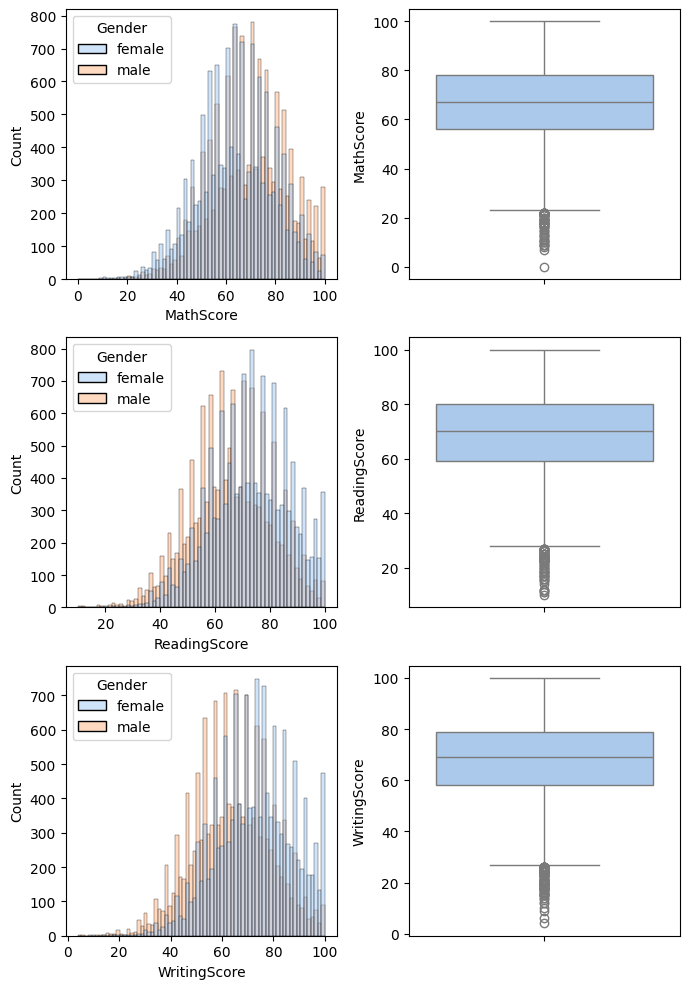

In [41]:
plt.rcParams['figure.autolayout'] = True
fig, axes = plt.subplots(3, 2, figsize=[7.0, 10.0])
sns.histplot(cleaned_student_scores, x='MathScore', hue='Gender', ax=axes[0,0])
sns.boxplot(cleaned_student_scores, y='MathScore', ax=axes[0,1])
sns.histplot(cleaned_student_scores, x='ReadingScore', hue='Gender', ax=axes[1,0])
sns.boxplot(cleaned_student_scores, y='ReadingScore', ax=axes[1,1])
sns.histplot(cleaned_student_scores, x='WritingScore', hue='Gender', ax=axes[2,0])
sns.boxplot(cleaned_student_scores, y='WritingScore', ax=axes[2,1])

Math, Reading & Writing score all have left-skewed distribution. Most Student have Math, Reading & Writing scores of ~60 to ~80.  
In general, male students have higher scores in Math exam while female students have higher scores in Reading & Writing exam.

### Weekly Study Hours & Student Score

<Axes: xlabel='WklyStudyHours', ylabel='WritingScore'>

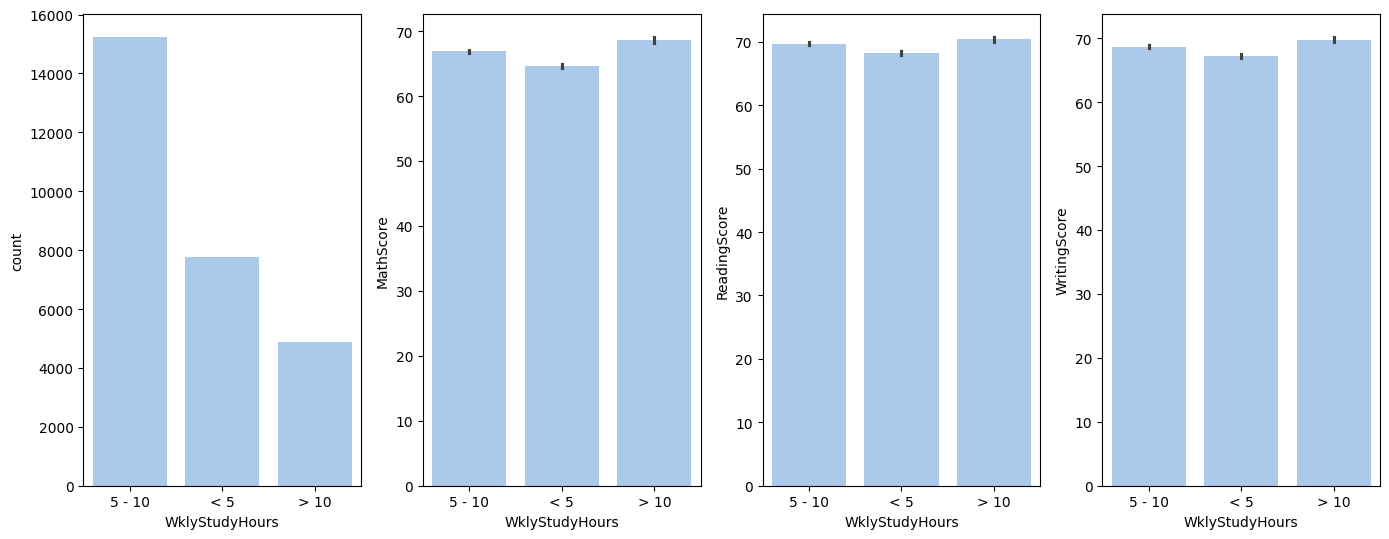

In [42]:
plt.rcParams['figure.figsize'] = [14.0, 5.5]
fig, axes = plt.subplots(1, 4)
sns.countplot(cleaned_student_scores, x='WklyStudyHours', ax=axes[0])
sns.barplot(cleaned_student_scores, x='WklyStudyHours', y='MathScore', ax=axes[1])
sns.barplot(cleaned_student_scores, x='WklyStudyHours', y='ReadingScore', ax=axes[2])
sns.barplot(cleaned_student_scores, x='WklyStudyHours', y='WritingScore', ax=axes[3])

The greater the weekly study hours, the higher the exam scores in Math, Reading & Writing exam.

### Gender & Student Score

<Axes: xlabel='Gender', ylabel='WritingScore'>

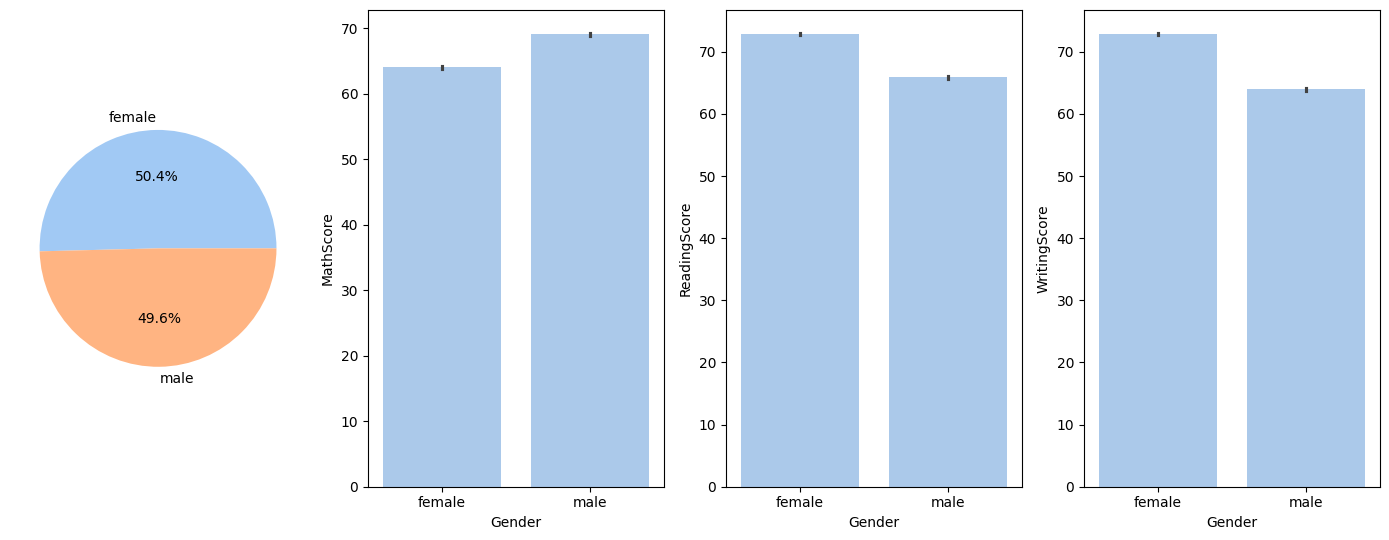

In [43]:
fig, axes = plt.subplots(1, 4)
Gender_count = cleaned_student_scores['Gender'].value_counts()
Gender_label = Gender_count.index
axes[0].pie(Gender_count, labels=Gender_label, autopct='%.1f%%')
sns.barplot(cleaned_student_scores, x='Gender', y='MathScore', ax=axes[1])
sns.barplot(cleaned_student_scores, x='Gender', y='ReadingScore', ax=axes[2])
sns.barplot(cleaned_student_scores, x='Gender', y='WritingScore', ax=axes[3])

Gender proportion was almost equal. MathScore for male student was higher, ReadingScore & WritingScore for female student were higher.

### EthnicGroup & Student Score

[Text(0, 0, 'group A'),
 Text(1, 0, 'group B'),
 Text(2, 0, 'group C'),
 Text(3, 0, 'group D'),
 Text(4, 0, 'group E')]

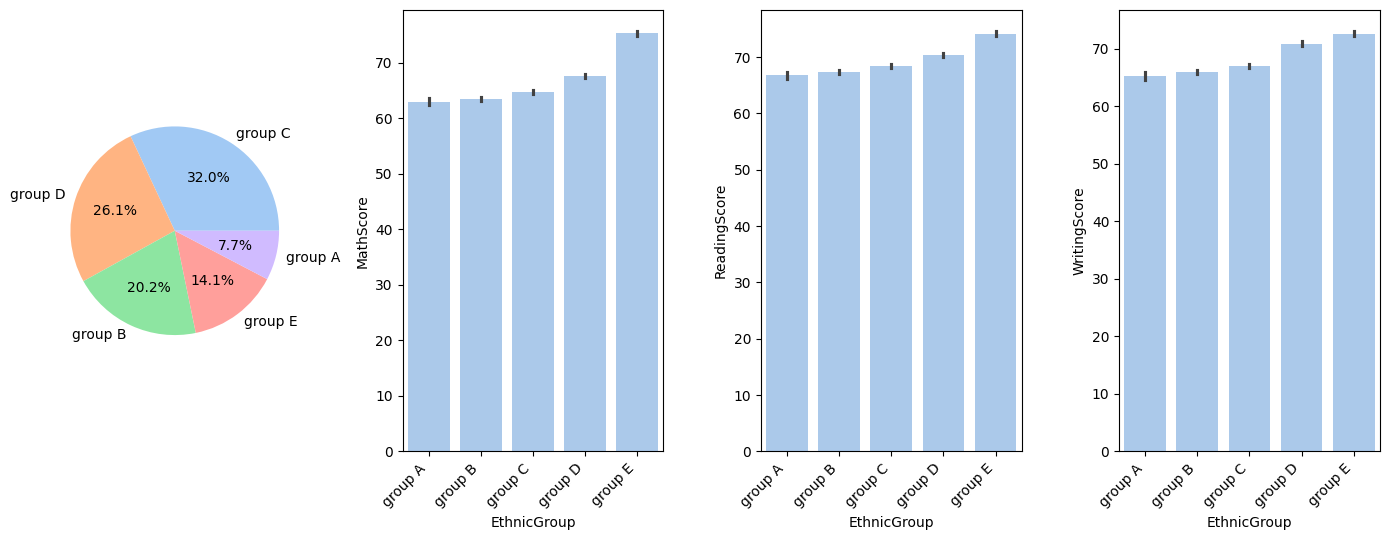

In [44]:
fig, axes = plt.subplots(1, 4)
EthnicGroup_count = cleaned_student_scores['EthnicGroup'].value_counts()
EthnicGroup_label = EthnicGroup_count.index
axes[0].pie(EthnicGroup_count, labels=EthnicGroup_label, autopct='%.1f%%')
sns.barplot(cleaned_student_scores, x='EthnicGroup', y='MathScore', ax=axes[1])
sns.barplot(cleaned_student_scores, x='EthnicGroup', y='ReadingScore', ax=axes[2])
sns.barplot(cleaned_student_scores, x='EthnicGroup', y='WritingScore', ax=axes[3])
axes[1].set_xticks(axes[1].get_xticks())
axes[2].set_xticks(axes[2].get_xticks())
axes[3].set_xticks(axes[3].get_xticks())
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, horizontalalignment='right')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, horizontalalignment='right')
axes[3].set_xticklabels(axes[3].get_xticklabels(), rotation=45, horizontalalignment='right')

Most students belong to EthnicGroup C. Students with EthnicGroup E have highest scores in Math, Reading & Writing score.

## ParentEduc & Student Score

[Text(0, 0, "associate's degree"),
 Text(1, 0, "bachelor's degree"),
 Text(2, 0, 'high school'),
 Text(3, 0, "master's degree"),
 Text(4, 0, 'some college')]

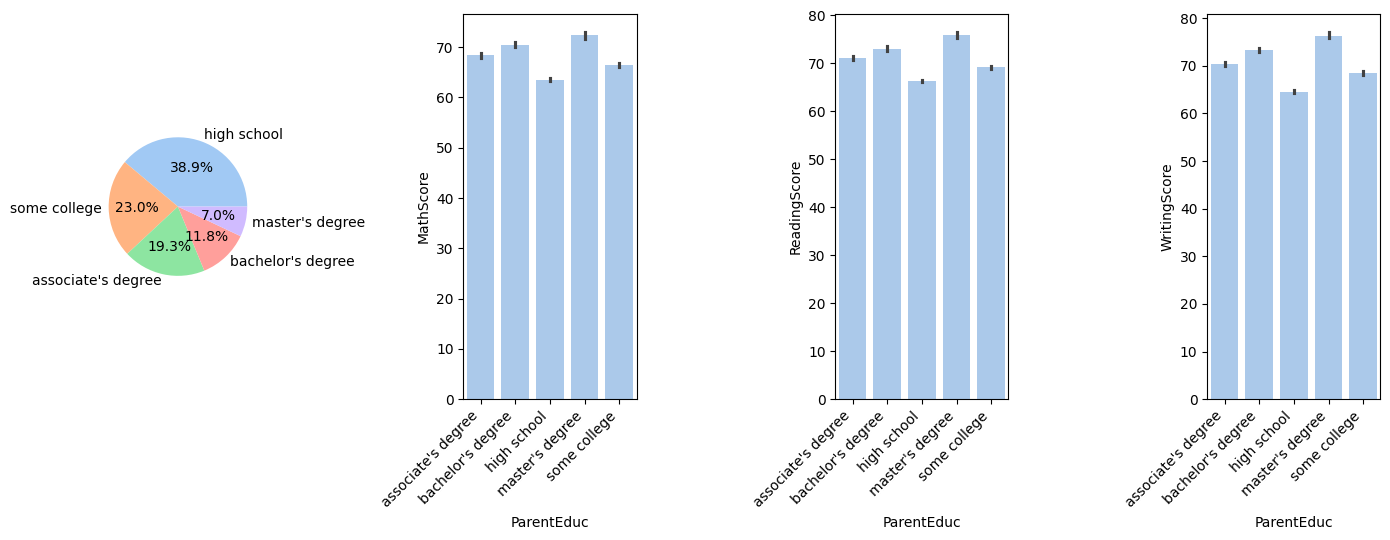

In [45]:
fig, axes = plt.subplots(1, 4)
ParentEduc_count = cleaned_student_scores['ParentEduc'].value_counts()
ParentEduc_label = ParentEduc_count.index
axes[0].pie(ParentEduc_count, labels=ParentEduc_label, autopct='%.1f%%')
sns.barplot(cleaned_student_scores, x='ParentEduc', y='MathScore', ax=axes[1])
sns.barplot(cleaned_student_scores, x='ParentEduc', y='ReadingScore', ax=axes[2])
sns.barplot(cleaned_student_scores, x='ParentEduc', y='WritingScore', ax=axes[3])
axes[1].set_xticks(axes[1].get_xticks())
axes[2].set_xticks(axes[2].get_xticks())
axes[3].set_xticks(axes[3].get_xticks())
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, horizontalalignment='right')
axes[2].set_xticklabels(axes[1].get_xticklabels(), rotation=45, horizontalalignment='right')
axes[3].set_xticklabels(axes[1].get_xticklabels(), rotation=45, horizontalalignment='right')

Most parents have high school education. The higher the parents' education, the higher the scores in Math, Reading & Writing.

### LunchType & Student Score

<Axes: xlabel='LunchType', ylabel='WritingScore'>

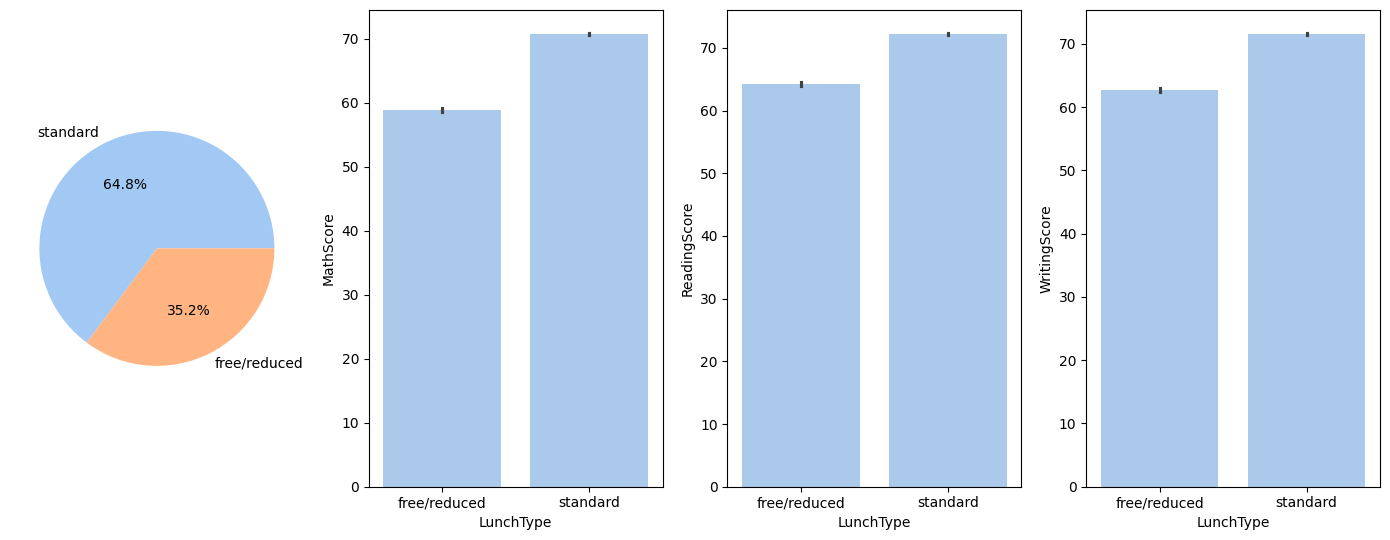

In [46]:
fig, axes = plt.subplots(1, 4)
LunchType_count = cleaned_student_scores['LunchType'].value_counts()
LunchType_label = LunchType_count.index
axes[0].pie(LunchType_count, labels=LunchType_label, autopct='%.1f%%')
sns.barplot(cleaned_student_scores, x='LunchType', y='MathScore', ax=axes[1])
sns.barplot(cleaned_student_scores, x='LunchType', y='ReadingScore', ax=axes[2])
sns.barplot(cleaned_student_scores, x='LunchType', y='WritingScore', ax=axes[3])

Most students have standard LunchType. Students with standard LunchType generally have higher scores in all the exams.

### TestPrep & Student Score

<Axes: xlabel='TestPrep', ylabel='WritingScore'>

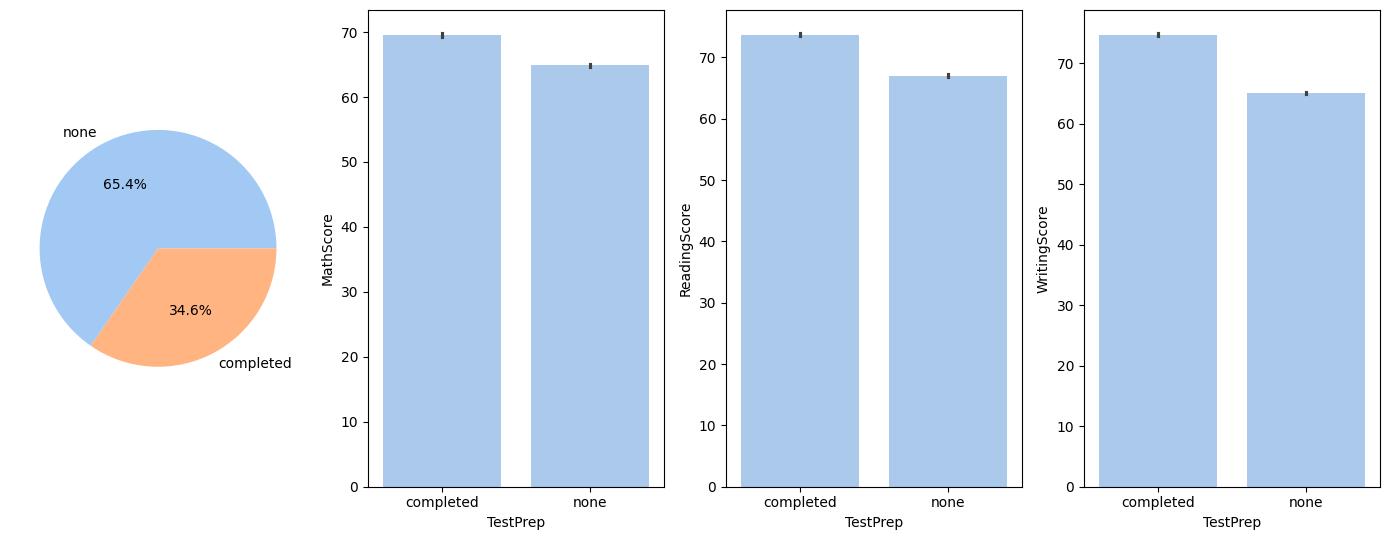

In [47]:
fig, axes = plt.subplots(1, 4)
TestPrep_count = cleaned_student_scores['TestPrep'].value_counts()
TestPrep_label = TestPrep_count.index
axes[0].pie(TestPrep_count, labels=TestPrep_label, autopct='%.1f%%')
sns.barplot(cleaned_student_scores, x='TestPrep', y='MathScore', ax=axes[1])
sns.barplot(cleaned_student_scores, x='TestPrep', y='ReadingScore', ax=axes[2])
sns.barplot(cleaned_student_scores, x='TestPrep', y='WritingScore', ax=axes[3])

Most students haven't completed preliminary test. Students who have completed preliminary test generally have higher scores in all the exam.

### ParentMaritalStatus & Student Score

<Axes: xlabel='ParentMaritalStatus', ylabel='WritingScore'>

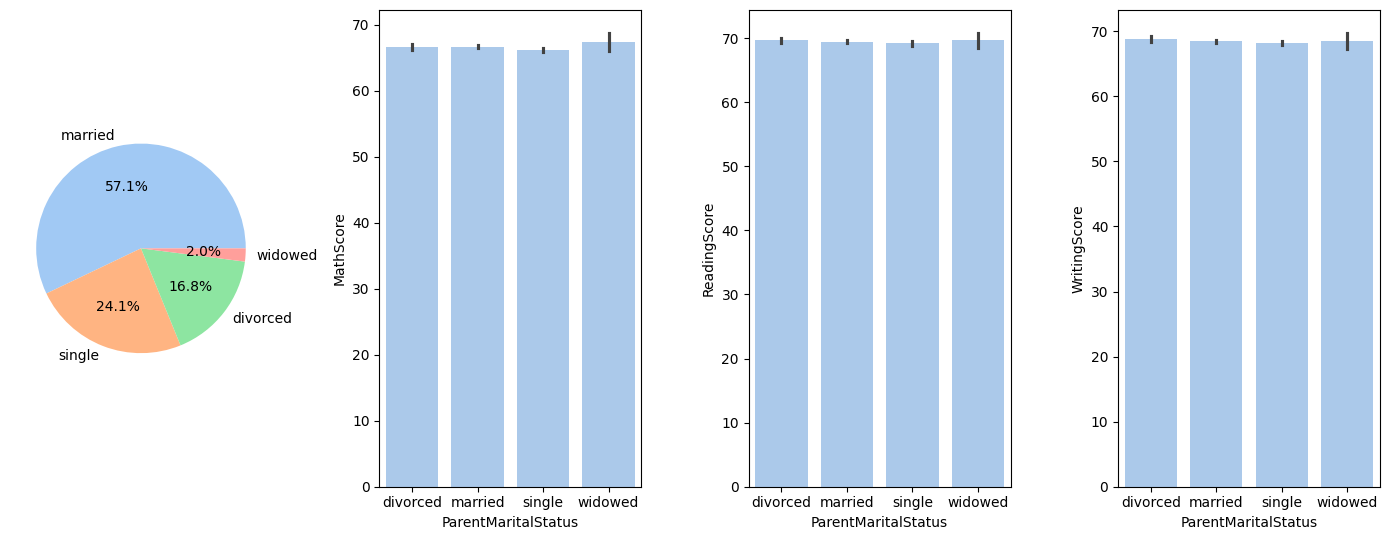

In [48]:
fig, axes = plt.subplots(1, 4)
ParentMaritalStatus_count = cleaned_student_scores['ParentMaritalStatus'].value_counts()
ParentMaritalStatus_label = ParentMaritalStatus_count.index
axes[0].pie(ParentMaritalStatus_count, labels=ParentMaritalStatus_label, autopct='%.1f%%')
sns.barplot(cleaned_student_scores, x='ParentMaritalStatus', y='MathScore', ax=axes[1])
sns.barplot(cleaned_student_scores, x='ParentMaritalStatus', y='ReadingScore', ax=axes[2])
sns.barplot(cleaned_student_scores, x='ParentMaritalStatus', y='WritingScore', ax=axes[3])

Parent marital status have no significant impact on the student scores.

### PracticeSport & Student Scores

<Axes: xlabel='PracticeSport', ylabel='WritingScore'>

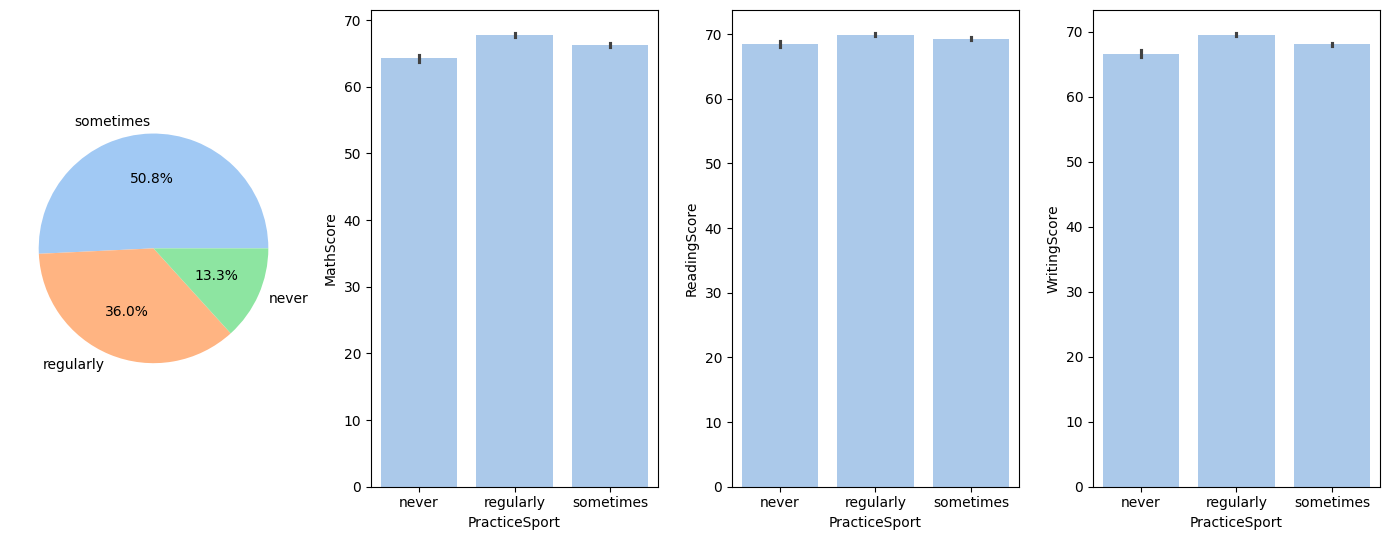

In [49]:
fig, axes = plt.subplots(1, 4)
PracticeSport_count = cleaned_student_scores['PracticeSport'].value_counts()
PracticeSport_label = PracticeSport_count.index
axes[0].pie(PracticeSport_count, labels=PracticeSport_label, autopct='%.1f%%')
sns.barplot(cleaned_student_scores, x='PracticeSport', y='MathScore', ax=axes[1])
sns.barplot(cleaned_student_scores, x='PracticeSport', y='ReadingScore', ax=axes[2])
sns.barplot(cleaned_student_scores, x='PracticeSport', y='WritingScore', ax=axes[3])

Most students practiced sport sometimes or regularly. Student who did not practice sport have a bit lower scores in all the exams than the students who did practice sport.

### IsFirstChild & Student Scores

<Axes: xlabel='IsFirstChild', ylabel='WritingScore'>

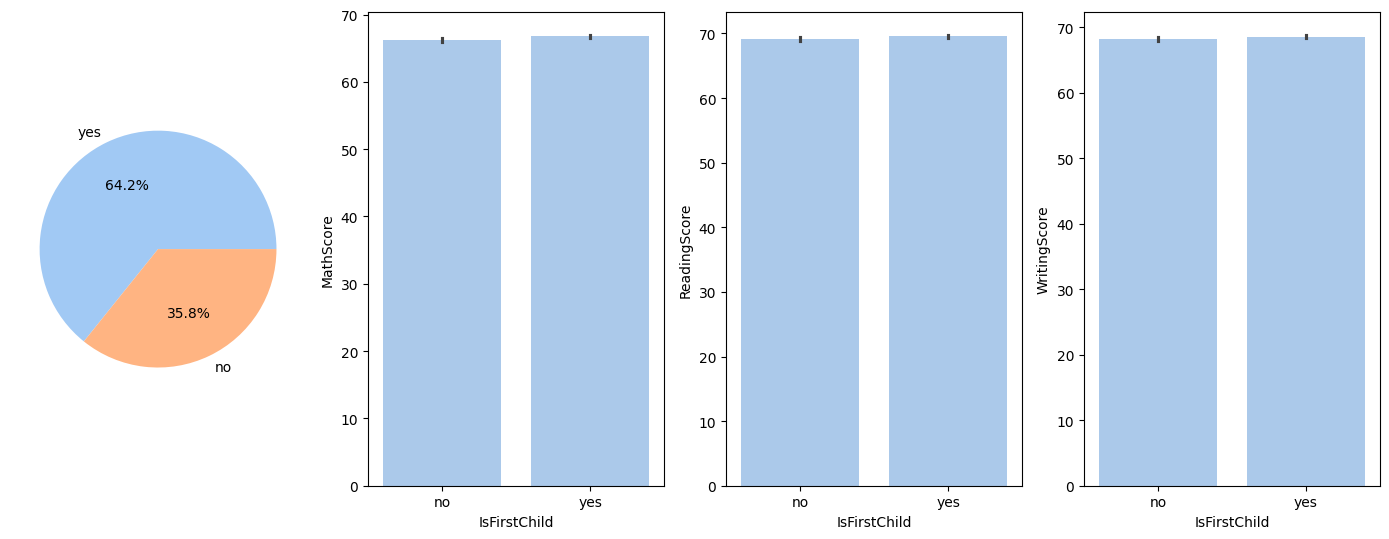

In [50]:
fig, axes = plt.subplots(1, 4)
IsFirstChild_count = cleaned_student_scores['IsFirstChild'].value_counts()
IsFirstChild_label = IsFirstChild_count.index
axes[0].pie(IsFirstChild_count, labels=IsFirstChild_label, autopct='%.1f%%')
sns.barplot(cleaned_student_scores, x='IsFirstChild', y='MathScore', ax=axes[1])
sns.barplot(cleaned_student_scores, x='IsFirstChild', y='ReadingScore', ax=axes[2])
sns.barplot(cleaned_student_scores, x='IsFirstChild', y='WritingScore', ax=axes[3])

Whether the student was the first child has no significant impact on the student scores in all the exam.

### NrSiblings & Student Scores

<Axes: xlabel='NrSiblings', ylabel='WritingScore'>

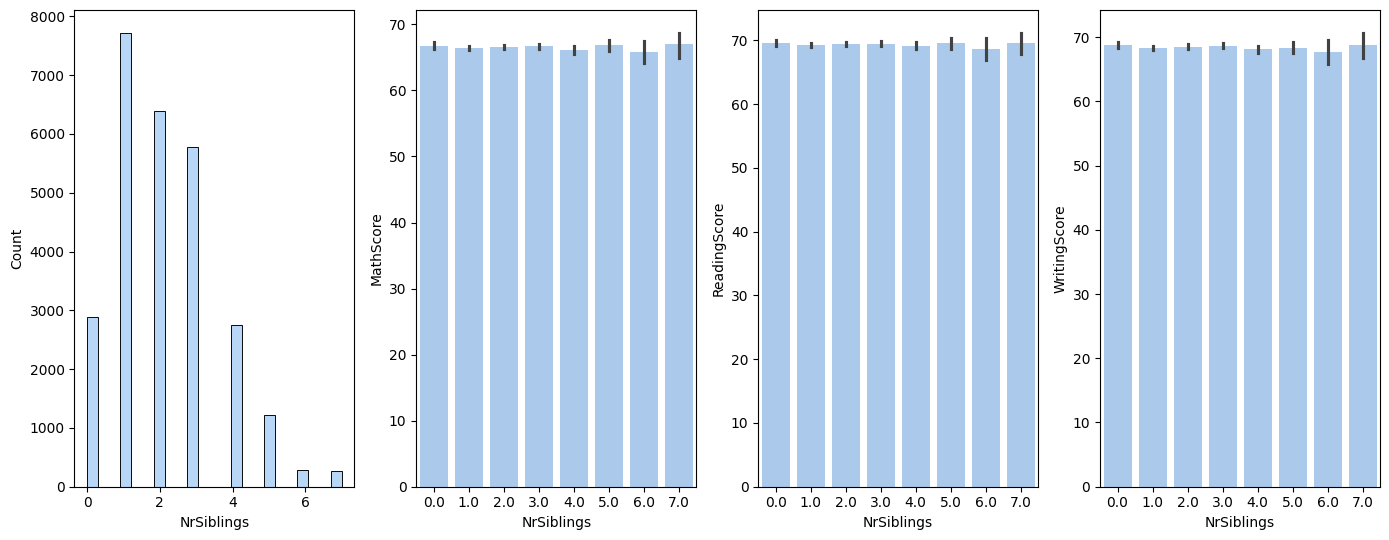

In [51]:
fig, axes = plt.subplots(1, 4)
sns.histplot(cleaned_student_scores, x='NrSiblings', ax=axes[0], binwidth=0.3)
sns.barplot(cleaned_student_scores, x='NrSiblings', y='MathScore', ax=axes[1])
sns.barplot(cleaned_student_scores, x='NrSiblings', y='ReadingScore', ax=axes[2])
sns.barplot(cleaned_student_scores, x='NrSiblings', y='WritingScore', ax=axes[3])

Most students have 1 sibling, then 2 siblings & 3 siblings. The number of siblings of the student has no signifacant impact on the student scores in all the exam.

### TransportMeans & Student Scores

<Axes: xlabel='TransportMeans', ylabel='WritingScore'>

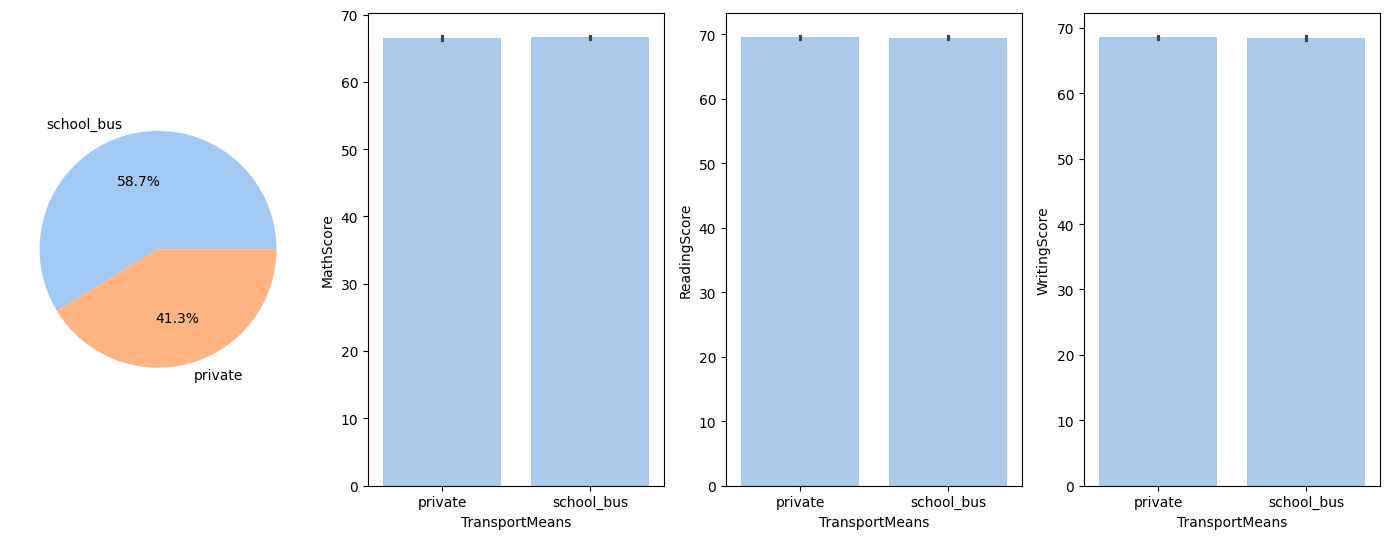

In [52]:
fig, axes = plt.subplots(1, 4)
TransportMeans_count = cleaned_student_scores['TransportMeans'].value_counts()
TransportMeans_label = TransportMeans_count.index
axes[0].pie(TransportMeans_count, labels=TransportMeans_label, autopct='%.1f%%')
sns.barplot(cleaned_student_scores, x='TransportMeans', y='MathScore', ax=axes[1])
sns.barplot(cleaned_student_scores, x='TransportMeans', y='ReadingScore', ax=axes[2])
sns.barplot(cleaned_student_scores, x='TransportMeans', y='WritingScore', ax=axes[3])

Most students took school bus. Transport means has no sigfinicant impact on the student scores for all the exam.

## Analyze The Data

In [53]:
import statsmodels.api as sm

In [54]:
lr_student_scores = cleaned_student_scores.copy()
lr_student_scores.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


Remove variables that have no significant impact on the student scores

In [55]:
lr_student_scores = lr_student_scores.drop(['ParentMaritalStatus', 'IsFirstChild', 'NrSiblings', 'TransportMeans'], axis=1)
lr_student_scores.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,PracticeSport,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,regularly,< 5,71,71,74
1,female,group C,some college,standard,NaN,sometimes,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,sometimes,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,never,5 - 10,45,56,42
4,male,group C,some college,standard,none,sometimes,5 - 10,76,78,75


In [56]:
lr_student_scores = pd.get_dummies(lr_student_scores, drop_first=True, columns=['Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep', 'PracticeSport', 'WklyStudyHours'], dtype=int)
lr_student_scores

,MathScore,ReadingScore,WritingScore,Gender_male,EthnicGroup_group B,EthnicGroup_group C,EthnicGroup_group D,EthnicGroup_group E,ParentEduc_bachelor's degree,ParentEduc_high school,ParentEduc_master's degree,ParentEduc_some college,LunchType_standard,TestPrep_none,PracticeSport_regularly,PracticeSport_sometimes,WklyStudyHours_< 5,WklyStudyHours_> 10
0,71,71,74,0,0,0,0,0,1,0,0,0,1,1,1,0,1,0
1,69,90,88,0,0,1,0,0,0,0,0,1,1,0,0,1,0,0
2,87,93,91,0,1,0,0,0,0,0,1,0,1,1,0,1,1,0
3,45,56,42,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,76,78,75,1,0,1,0,0,0,0,0,1,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,59,61,65,0,0,0,1,0,0,1,0,0,1,1,0,1,0,0
30637,58,53,51,1,0,0,0,1,0,1,0,0,1,1,1,0,0,0
30638,61,70,67,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0
30639,82,90,93,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0


In [57]:
y_MathScore = lr_student_scores['MathScore']
y_ReadingScore = lr_student_scores['ReadingScore']
y_WritingScore = lr_student_scores['WritingScore']

In [58]:
x = lr_student_scores.drop(['MathScore', 'ReadingScore', 'WritingScore'], axis=1)

In [59]:
pd.set_option('display.max_columns', None)
x.corr().abs() > 0.8

,Gender_male,EthnicGroup_group B,EthnicGroup_group C,EthnicGroup_group D,EthnicGroup_group E,ParentEduc_bachelor's degree,ParentEduc_high school,ParentEduc_master's degree,ParentEduc_some college,LunchType_standard,TestPrep_none,PracticeSport_regularly,PracticeSport_sometimes,WklyStudyHours_< 5,WklyStudyHours_> 10
Gender_male,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
EthnicGroup_group B,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
EthnicGroup_group C,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
EthnicGroup_group D,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
EthnicGroup_group E,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
ParentEduc_bachelor's degree,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
ParentEduc_high school,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
ParentEduc_master's degree,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
ParentEduc_some college,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
LunchType_standard,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False


<Axes: >

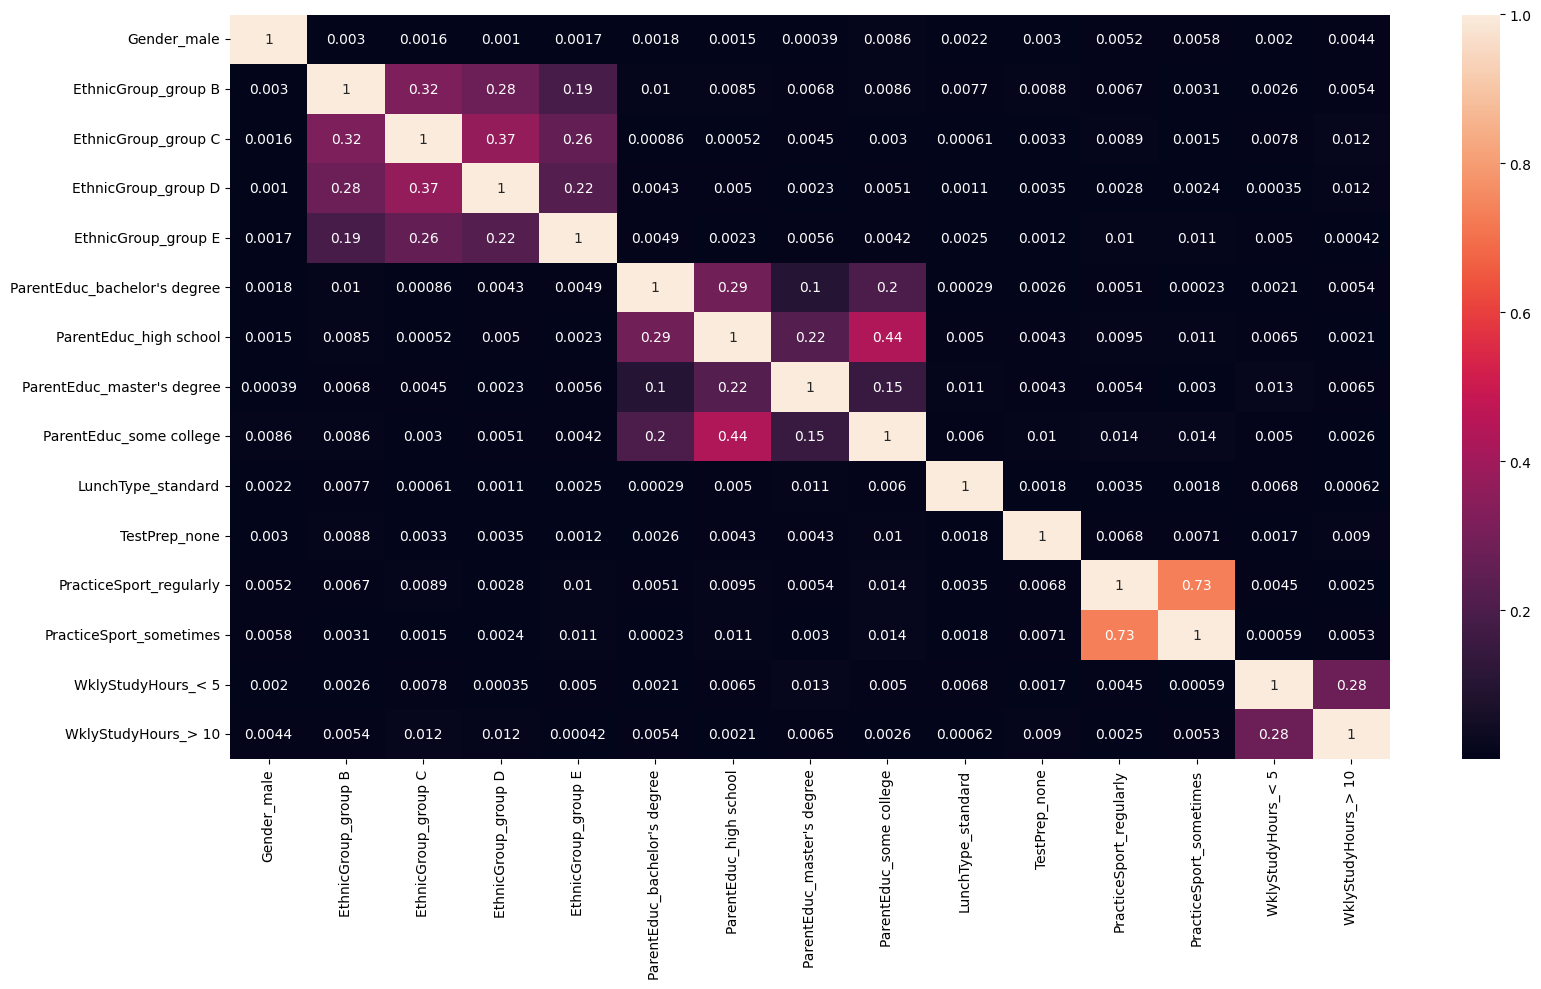

In [60]:
plt.figure(figsize=(17,10))
sns.heatmap(x.corr().abs(), annot=True)

The correlation between PracticeSport_sometimes & PracticeSport_regularly is higher at 0.73.  
Hence, will remove PracticeSport_sometimes & keep PracticeSport_regularly.  
The corr between the rest of variables all below 0.8.

<Axes: >

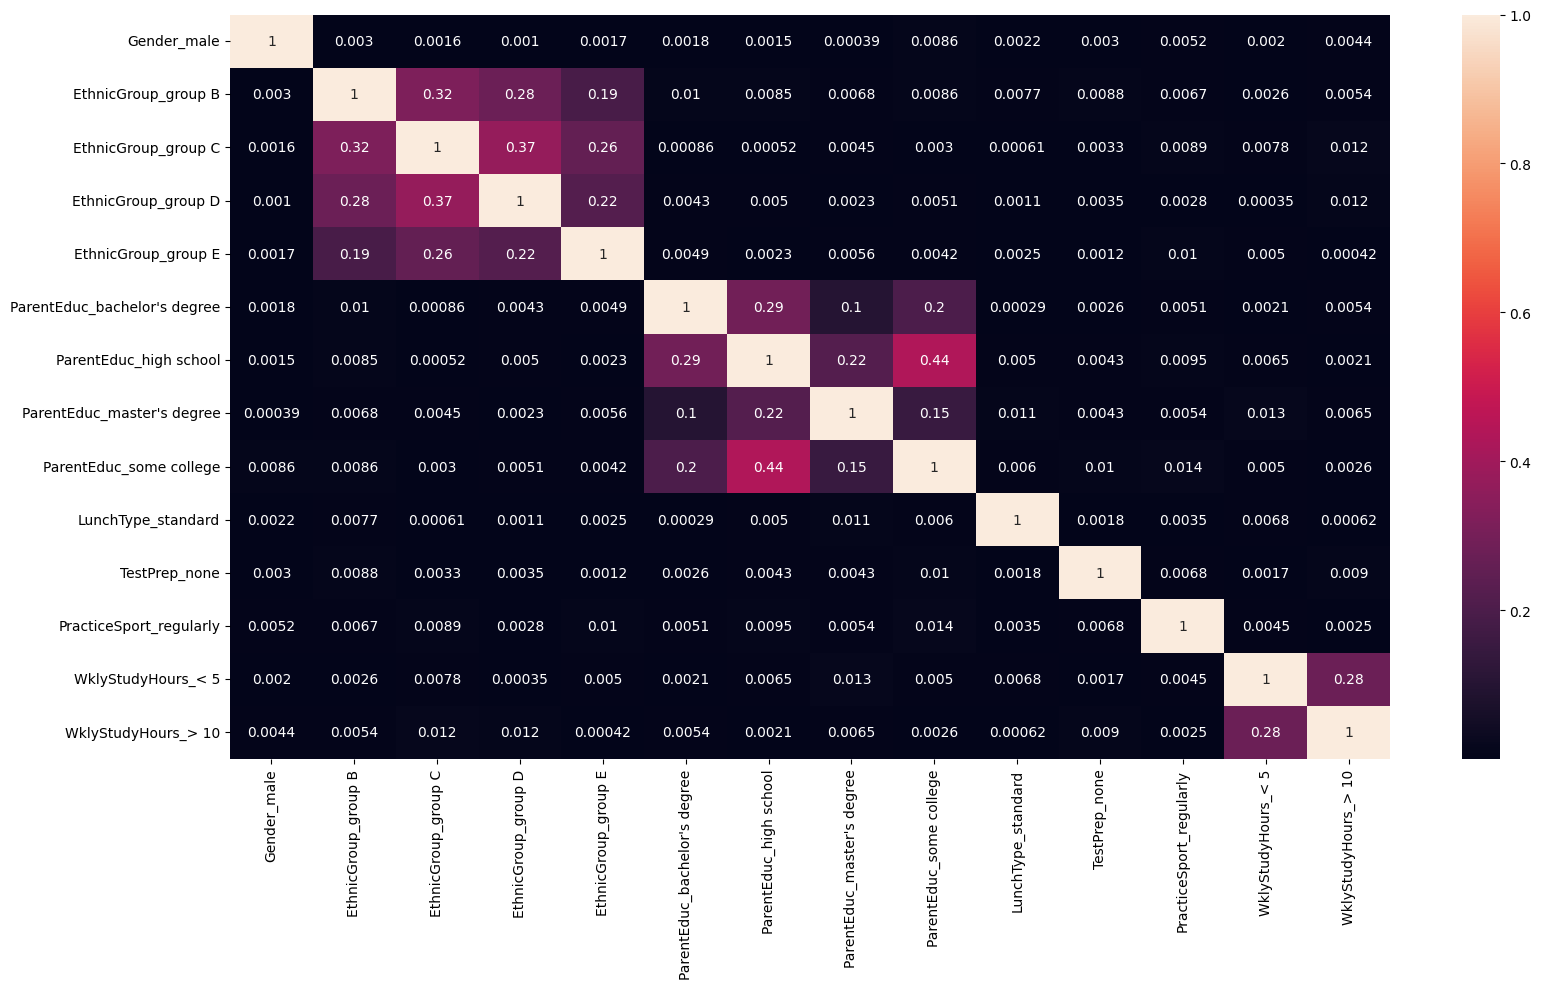

In [61]:
x = x.drop(['PracticeSport_sometimes'], axis=1)
plt.figure(figsize=(17,10))
sns.heatmap(x.corr().abs(), annot=True)

In [62]:
x = sm.add_constant(x)
x

,const,Gender_male,EthnicGroup_group B,EthnicGroup_group C,EthnicGroup_group D,EthnicGroup_group E,ParentEduc_bachelor's degree,ParentEduc_high school,ParentEduc_master's degree,ParentEduc_some college,LunchType_standard,TestPrep_none,PracticeSport_regularly,WklyStudyHours_< 5,WklyStudyHours_> 10
0,1.0,0,0,0,0,0,1,0,0,0,1,1,1,1,0
1,1.0,0,0,1,0,0,0,0,0,1,1,0,0,0,0
2,1.0,0,1,0,0,0,0,0,1,0,1,1,0,1,0
3,1.0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
4,1.0,1,0,1,0,0,0,0,0,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,1.0,0,0,0,1,0,0,1,0,0,1,1,0,0,0
30637,1.0,1,0,0,0,1,0,1,0,0,1,1,1,0,0
30638,1.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
30639,1.0,0,0,0,1,0,0,0,0,0,1,0,1,0,0


In [63]:
model_MathScore = sm.OLS(y_MathScore, x).fit()
model_MathScore.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              MathScore   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.287
Method:                 Least Squares   F-statistic:                     828.1
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        13:32:15   Log-Likelihood:            -1.1469e+05
No. Observations:               28796   AIC:                         2.294e+05
Df Residuals:                   28781   BIC:                         2.295e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           58.3383      0.320    182.309      0.000      57.711      58.966
Gender_male                      5.0567      0.153     33.029      0.000       4.757       5.357
EthnicGroup_group B             -0.7653      0.274     -2.790      0.005      -1.303      -0.228
EthnicGroup_group C              0.2809      0.253      1.111      0.266      -0.215       0.776
EthnicGroup_group D              3.1852      0.261     12.190      0.000       2.673       3.697
EthnicGroup_group E             10.8441      0.298     36.430      0.000      10.261      11.428
ParentEduc_bachelor's degree     1.9807      0.283      6.992      0.000       1.425       2.536
ParentEduc_high school          -4.9028      0.213    -22.996      0.000      -5.321      -4.485
ParentEduc_master's degree       4.2979      0.337     12.738      0.000       3.637       4.959
ParentEduc_some college         -2.1499      0.236     -9.097      0.000      -2.613      -1.687
LunchType_standard              11.9521      0.160     74.562      0.000      11.638      12.266
TestPrep_none                   -4.3367      0.157    -27.569      0.000      -4.645      -4.028
PracticeSport_regularly          1.9410      0.160     12.111      0.000       1.627       2.255
WklyStudyHours_< 5              -2.3796      0.179    -13.262      0.000      -2.731      -2.028
WklyStudyHours_> 10              1.7424      0.212      8.220      0.000       1.327       2.158
==============================================================================
Omnibus:                      292.318   Durbin-Watson:                   1.994
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              280.462
Skew:                          -0.214   Prob(JB):                     1.25e-61
Kurtosis:                       2.774   Cond. No.                         11.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

When the significance interval is set to 0.05, the p-values show that the model considers the variable 'EthnicGroup_group C' have no significant impact on students Math score.

Hence, should remove these variables & rebuild linear regression model.

In [64]:
model_ReadingScore = sm.OLS(y_ReadingScore, x).fit()
model_ReadingScore.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           ReadingScore   R-squared:                       0.228
Model:                            OLS   Adj. R-squared:                  0.228
Method:                 Least Squares   F-statistic:                     608.1
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        13:32:15   Log-Likelihood:            -1.1466e+05
No. Observations:               28796   AIC:                         2.293e+05
Df Residuals:                   28781   BIC:                         2.295e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           71.5646      0.320    223.885      0.000      70.938      72.191
Gender_male                     -6.9437      0.153    -45.404      0.000      -7.243      -6.644
EthnicGroup_group B             -0.4012      0.274     -1.464      0.143      -0.938       0.136
EthnicGroup_group C              0.6680      0.252      2.646      0.008       0.173       1.163
EthnicGroup_group D              2.5984      0.261      9.955      0.000       2.087       3.110
EthnicGroup_group E              6.4612      0.297     21.729      0.000       5.878       7.044
ParentEduc_bachelor's degree     1.8315      0.283      6.473      0.000       1.277       2.386
ParentEduc_high school          -4.8392      0.213    -22.722      0.000      -5.257      -4.422
ParentEduc_master's degree       4.8651      0.337     14.435      0.000       4.204       5.526
ParentEduc_some college         -2.2304      0.236     -9.448      0.000      -2.693      -1.768
LunchType_standard               8.0527      0.160     50.290      0.000       7.739       8.367
TestPrep_none                   -6.0903      0.157    -38.759      0.000      -6.398      -5.782
PracticeSport_regularly          0.8017      0.160      5.008      0.000       0.488       1.115
WklyStudyHours_< 5              -1.4805      0.179     -8.260      0.000      -1.832      -1.129
WklyStudyHours_> 10              0.7712      0.212      3.642      0.000       0.356       1.186
==============================================================================
Omnibus:                      376.575   Durbin-Watson:                   2.005
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              349.570
Skew:                          -0.231   Prob(JB):                     1.24e-76
Kurtosis:                       2.721   Cond. No.                         11.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The p-values show that the model considers the variable 'EthnicGroup_group B' have no significant impact on students Reading score.

Hence, should remove these variables & rebuild linear regression model.

In [65]:
model_WritingScore = sm.OLS(y_WritingScore, x).fit()
model_WritingScore.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           WritingScore   R-squared:                       0.324
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     985.5
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        13:32:15   Log-Likelihood:            -1.1406e+05
No. Observations:               28796   AIC:                         2.281e+05
Df Residuals:                   28781   BIC:                         2.283e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           72.0631      0.313    230.172      0.000      71.449      72.677
Gender_male                     -8.8593      0.150    -59.145      0.000      -9.153      -8.566
EthnicGroup_group B             -0.5629      0.268     -2.097      0.036      -1.089      -0.037
EthnicGroup_group C              0.4932      0.247      1.994      0.046       0.008       0.978
EthnicGroup_group D              4.3770      0.256     17.121      0.000       3.876       4.878
EthnicGroup_group E              6.1449      0.291     21.099      0.000       5.574       6.716
ParentEduc_bachelor's degree     2.8985      0.277     10.459      0.000       2.355       3.442
ParentEduc_high school          -5.8615      0.209    -28.100      0.000      -6.270      -5.453
ParentEduc_master's degree       6.2235      0.330     18.853      0.000       5.577       6.871
ParentEduc_some college         -2.1746      0.231     -9.405      0.000      -2.628      -1.721
LunchType_standard               8.9436      0.157     57.026      0.000       8.636       9.251
TestPrep_none                   -8.7151      0.154    -56.627      0.000      -9.017      -8.413
PracticeSport_regularly          1.7701      0.157     11.289      0.000       1.463       2.077
WklyStudyHours_< 5              -1.5929      0.176     -9.074      0.000      -1.937      -1.249
WklyStudyHours_> 10              1.1768      0.207      5.674      0.000       0.770       1.583
==============================================================================
Omnibus:                      382.083   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              363.176
Skew:                          -0.242   Prob(JB):                     1.37e-79
Kurtosis:                       2.739   Cond. No.                         11.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Although 'EthnicGroup_group B' & 'EthnicGroup_group C' have p-values < 0.05, the 2 variables have higher p-value at 0.036 & 0.046 respectively.  
In addition, this 2 variables are also considered to have no impact on Reading score & Math score.

Hence, we will remove the 2 variables & rebuild all the linear regression models.

In [66]:
x = x.drop(['EthnicGroup_group B', 'EthnicGroup_group C'], axis=1)
x

,const,Gender_male,EthnicGroup_group D,EthnicGroup_group E,ParentEduc_bachelor's degree,ParentEduc_high school,ParentEduc_master's degree,ParentEduc_some college,LunchType_standard,TestPrep_none,PracticeSport_regularly,WklyStudyHours_< 5,WklyStudyHours_> 10
0,1.0,0,0,0,1,0,0,0,1,1,1,1,0
1,1.0,0,0,0,0,0,0,1,1,0,0,0,0
2,1.0,0,0,0,0,0,1,0,1,1,0,1,0
3,1.0,1,0,0,0,0,0,0,0,1,0,0,0
4,1.0,1,0,0,0,0,0,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,1.0,0,1,0,0,1,0,0,1,1,0,0,0
30637,1.0,1,0,1,0,1,0,0,1,1,1,0,0
30638,1.0,0,0,0,0,1,0,0,0,0,0,0,0
30639,1.0,0,1,0,0,0,0,0,1,0,1,0,0


In [67]:
model_MathScore = sm.OLS(y_MathScore, x).fit()
model_MathScore.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              MathScore   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     963.6
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        13:32:15   Log-Likelihood:            -1.1470e+05
No. Observations:               28796   AIC:                         2.294e+05
Df Residuals:                   28783   BIC:                         2.295e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           58.2305      0.259    224.898      0.000      57.723      58.738
Gender_male                      5.0588      0.153     33.031      0.000       4.759       5.359
EthnicGroup_group D              3.2831      0.183     17.977      0.000       2.925       3.641
EthnicGroup_group E             10.9418      0.232     47.221      0.000      10.488      11.396
ParentEduc_bachelor's degree     1.9897      0.283      7.022      0.000       1.434       2.545
ParentEduc_high school          -4.9045      0.213    -22.996      0.000      -5.323      -4.487
ParentEduc_master's degree       4.2942      0.338     12.723      0.000       3.633       4.956
ParentEduc_some college         -2.1455      0.236     -9.075      0.000      -2.609      -1.682
LunchType_standard              11.9569      0.160     74.571      0.000      11.643      12.271
TestPrep_none                   -4.3326      0.157    -27.535      0.000      -4.641      -4.024
PracticeSport_regularly          1.9470      0.160     12.146      0.000       1.633       2.261
WklyStudyHours_< 5              -2.3790      0.179    -13.255      0.000      -2.731      -2.027
WklyStudyHours_> 10              1.7413      0.212      8.212      0.000       1.326       2.157
==============================================================================
Omnibus:                      291.082   Durbin-Watson:                   1.995
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              279.575
Skew:                          -0.214   Prob(JB):                     1.96e-61
Kurtosis:                       2.776   Cond. No.                         9.58
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [68]:
model_ReadingScore = sm.OLS(y_ReadingScore, x).fit()
model_ReadingScore.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           ReadingScore   R-squared:                       0.228
Model:                            OLS   Adj. R-squared:                  0.227
Method:                 Least Squares   F-statistic:                     706.9
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        13:32:15   Log-Likelihood:            -1.1467e+05
No. Observations:               28796   AIC:                         2.294e+05
Df Residuals:                   28783   BIC:                         2.295e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           71.7563      0.259    277.431      0.000      71.249      72.263
Gender_male                     -6.9413      0.153    -45.372      0.000      -7.241      -6.641
EthnicGroup_group D              2.3984      0.182     13.147      0.000       2.041       2.756
EthnicGroup_group E              6.2611      0.231     27.049      0.000       5.807       6.715
ParentEduc_bachelor's degree     1.8404      0.283      6.502      0.000       1.286       2.395
ParentEduc_high school          -4.8400      0.213    -22.717      0.000      -5.258      -4.422
ParentEduc_master's degree       4.8674      0.337     14.437      0.000       4.207       5.528
ParentEduc_some college         -2.2267      0.236     -9.429      0.000      -2.690      -1.764
LunchType_standard               8.0547      0.160     50.288      0.000       7.741       8.369
TestPrep_none                   -6.0888      0.157    -38.738      0.000      -6.397      -5.781
PracticeSport_regularly          0.8105      0.160      5.061      0.000       0.497       1.124
WklyStudyHours_< 5              -1.4780      0.179     -8.243      0.000      -1.829      -1.127
WklyStudyHours_> 10              0.7671      0.212      3.621      0.000       0.352       1.182
==============================================================================
Omnibus:                      376.196   Durbin-Watson:                   2.006
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              349.519
Skew:                          -0.231   Prob(JB):                     1.27e-76
Kurtosis:                       2.722   Cond. No.                         9.58
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [69]:
model_WritingScore = sm.OLS(y_WritingScore, x).fit()
model_WritingScore.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           WritingScore   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.323
Method:                 Least Squares   F-statistic:                     1147.
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        13:32:15   Log-Likelihood:            -1.1407e+05
No. Observations:               28796   AIC:                         2.282e+05
Df Residuals:                   28783   BIC:                         2.283e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           72.1205      0.253    284.689      0.000      71.624      72.617
Gender_male                     -8.8570      0.150    -59.108      0.000      -9.151      -8.563
EthnicGroup_group D              4.3106      0.179     24.125      0.000       3.960       4.661
EthnicGroup_group E              6.0785      0.227     26.811      0.000       5.634       6.523
ParentEduc_bachelor's degree     2.9074      0.277     10.487      0.000       2.364       3.451
ParentEduc_high school          -5.8628      0.209    -28.095      0.000      -6.272      -5.454
ParentEduc_master's degree       6.2231      0.330     18.846      0.000       5.576       6.870
ParentEduc_some college         -2.1706      0.231     -9.384      0.000      -2.624      -1.717
LunchType_standard               8.9469      0.157     57.030      0.000       8.639       9.254
TestPrep_none                   -8.7124      0.154    -56.592      0.000      -9.014      -8.411
PracticeSport_regularly          1.7777      0.157     11.334      0.000       1.470       2.085
WklyStudyHours_< 5              -1.5912      0.176     -9.061      0.000      -1.935      -1.247
WklyStudyHours_> 10              1.1741      0.207      5.659      0.000       0.767       1.581
==============================================================================
Omnibus:                      381.165   Durbin-Watson:                   2.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              362.779
Skew:                          -0.242   Prob(JB):                     1.67e-79
Kurtosis:                       2.741   Cond. No.                         9.58
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [70]:
# Students to predict --> Gender: male, EthnicGroup: group E, ParentEduc: bachelor's degree, LunchType: standard, TestPrep: completed, ParentMaritalStatus: married, PracticeSport: sometimes, IsFirstChild: yes, NrSiblings: 3, TransportMeans: private, WklyStudyHours: 5 to 10.

In [71]:
student_to_predict = pd.DataFrame({"Gender": ['male'], "EthnicGroup": ['group E'], "ParentEduc": ['bachelor\'s degree'], "LunchType": ['standard'], "TestPrep": ['completed'], "ParentMaritalStatus": ['married'], "PracticeSport": ['sometimes'], "IsFirstChild": ['yes'], "NrSiblings": [3.0], "TransportMeans": ['private'], "WklyStudyHours": ['5 to 10']})
student_to_predict

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours
0,male,group E,bachelor's degree,standard,completed,married,sometimes,yes,3.0,private,5 to 10


In [72]:
x

,const,Gender_male,EthnicGroup_group D,EthnicGroup_group E,ParentEduc_bachelor's degree,ParentEduc_high school,ParentEduc_master's degree,ParentEduc_some college,LunchType_standard,TestPrep_none,PracticeSport_regularly,WklyStudyHours_< 5,WklyStudyHours_> 10
0,1.0,0,0,0,1,0,0,0,1,1,1,1,0
1,1.0,0,0,0,0,0,0,1,1,0,0,0,0
2,1.0,0,0,0,0,0,1,0,1,1,0,1,0
3,1.0,1,0,0,0,0,0,0,0,1,0,0,0
4,1.0,1,0,0,0,0,0,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,1.0,0,1,0,0,1,0,0,1,1,0,0,0
30637,1.0,1,0,1,0,1,0,0,1,1,1,0,0
30638,1.0,0,0,0,0,1,0,0,0,0,0,0,0
30639,1.0,0,1,0,0,0,0,0,1,0,1,0,0


In [73]:
student_to_predict['Gender'] = pd.Categorical(student_to_predict['Gender'], categories=['female', 'male'])
student_to_predict['EthnicGroup'] = pd.Categorical(student_to_predict['EthnicGroup'], categories=['group A', 'group B', 'group C', 'group D', 'group E'])
student_to_predict['ParentEduc'] = pd.Categorical(student_to_predict['ParentEduc'], categories=['associate\'s degree', 'bachelor\'s degree', 'high school', 'master\'s degree', 'some college'])
student_to_predict['LunchType'] = pd.Categorical(student_to_predict['LunchType'], categories=['free/reduced', 'standard'])
student_to_predict['TestPrep'] = pd.Categorical(student_to_predict['TestPrep'], categories=['completed', 'none'])
student_to_predict['PracticeSport'] = pd.Categorical(student_to_predict['PracticeSport'], categories=['never', 'regularly', 'sometimes'])
student_to_predict['WklyStudyHours'] = pd.Categorical(student_to_predict['WklyStudyHours'], categories=['5 - 10', '< 5', '> 10'])

In [74]:
student_to_predict = pd.get_dummies(student_to_predict, drop_first=True, columns=['Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep', 'PracticeSport', 'WklyStudyHours'], dtype=int)
student_to_predict

,ParentMaritalStatus,IsFirstChild,NrSiblings,TransportMeans,Gender_male,EthnicGroup_group B,EthnicGroup_group C,EthnicGroup_group D,EthnicGroup_group E,ParentEduc_bachelor's degree,ParentEduc_high school,ParentEduc_master's degree,ParentEduc_some college,LunchType_standard,TestPrep_none,PracticeSport_regularly,PracticeSport_sometimes,WklyStudyHours_< 5,WklyStudyHours_> 10
0,married,yes,3.0,private,1,0,0,0,1,1,0,0,0,1,0,0,1,0,0


In [75]:
student_to_predict = student_to_predict[["Gender_male", "EthnicGroup_group D", "EthnicGroup_group E", "ParentEduc_bachelor's degree", "ParentEduc_high school", "ParentEduc_master's degree", "ParentEduc_some college", "LunchType_standard", "TestPrep_none", "PracticeSport_regularly", "WklyStudyHours_< 5", "WklyStudyHours_> 10"]]
student_to_predict

,Gender_male,EthnicGroup_group D,EthnicGroup_group E,ParentEduc_bachelor's degree,ParentEduc_high school,ParentEduc_master's degree,ParentEduc_some college,LunchType_standard,TestPrep_none,PracticeSport_regularly,WklyStudyHours_< 5,WklyStudyHours_> 10
0,1,0,1,1,0,0,0,1,0,0,0,0


In [79]:
student_to_predict = sm.add_constant(student_to_predict, has_constant='add')
student_to_predict

,const,Gender_male,EthnicGroup_group D,EthnicGroup_group E,ParentEduc_bachelor's degree,ParentEduc_high school,ParentEduc_master's degree,ParentEduc_some college,LunchType_standard,TestPrep_none,PracticeSport_regularly,WklyStudyHours_< 5,WklyStudyHours_> 10
0,1.0,1,0,1,1,0,0,0,1,0,0,0,0


In [94]:
predicted_MathScore = model_MathScore.predict(student_to_predict)
predicted_MathScore = predicted_MathScore.loc[0]
print(f"The predicted Math Score for the student: {predicted_MathScore:.0f}")

The predicted Math Score for the student: 88


In [93]:
predicted_ReadingScore = model_ReadingScore.predict(student_to_predict)
predicted_ReadingScore = predicted_ReadingScore.loc[0]
print(f"The predicted Reading Score for the student: {predicted_ReadingScore:.0f}")

The predicted Reading Score for the student: 81


In [95]:
predicted_WritingScore = model_WritingScore.predict(student_to_predict)
predicted_WritingScore = predicted_WritingScore.loc[0]
print(f"The predicted Writing Score for the student: {predicted_WritingScore:.0f}")

The predicted Writing Score for the student: 81
